# Using Full Output for Diagnostics

Sometimes it helps to have a bigger picture of what the full output is doing.

These steps will guide you through how to get out gain more intuition from your runs.

In [1]:
#picaso
from picaso import justplotit as jpi
from picaso import justdoit as jdi
jpi.output_notebook()

Loading BokehJS ...

We will use a cloudy Jupiter again to guide us through the exercise.

In [2]:
opa = jdi.opannection(wave_range=[0.3,1])

case1 = jdi.inputs()

case1.phase_angle(0)

case1.gravity(gravity=25, gravity_unit=jdi.u.Unit('m/(s**2)'))

case1.star(opa, 6000,0.0122,4.437)

case1.atmosphere(filename = jdi.jupiter_pt(), sep=r'\s+')
case1.clouds(filename = jdi.jupiter_cld(), sep=r'\s+')

## Return ``PICASO`` Full Output

In [3]:
df = case1.spectrum(opa, full_output=True) #note the new last key
wno, alb, full_output = df['wavenumber'] , df['albedo'] , df['full_output']

## Visualizing Full Output

### Mixing Ratios

In [4]:
jpi.show(jpi.mixing_ratio(full_output))
#can also input any key word argument acceptable for bokeh.figure:
#show(jpi.mixing_ratio(full_output, plot_width=500, y_axis_type='linear',y_range=[10,1e-3]))

### Cloud Profile

Depending on your wavelength grid, you might exceed ``Jupyter Notebook's`` data rage limit. You can fix this by initiating jupyter notebook with a higher data rate limit.

``jupyter notebook --NotebookApp.iopub_data_rate_limit=10000000``

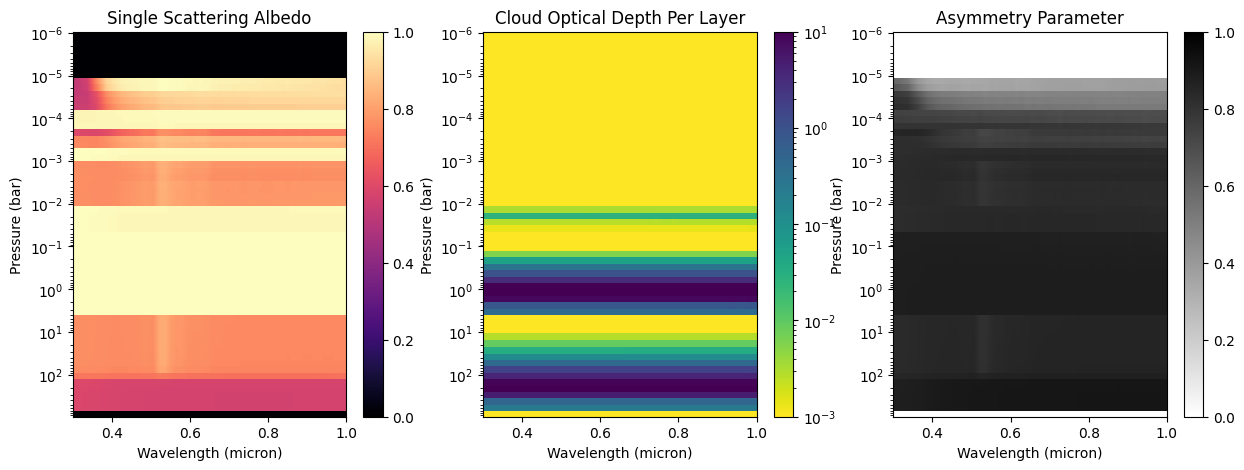

In [5]:
fig = jpi.cloud(full_output)

### Pressure-Temperature Profile

In [6]:
jpi.show(jpi.pt(full_output))

### Heatmap of Molecular, Cloud, and Rayleigh Scattering Opacity

This will show you where your molecular, cloud and rayleigh scattering opacity become optically thick ($\tau$~1). Blue regions of the plot are optically thin, while red are optically thick.

<Axes: title={'center': 'tauray'}, xlabel='Wavelength(um)', ylabel='Pressure(bars)'>

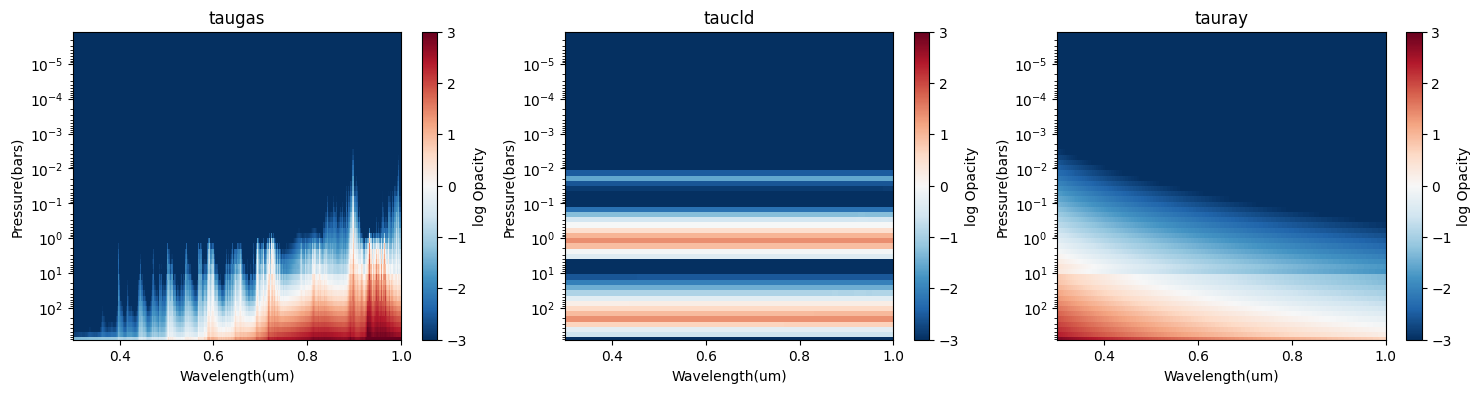

In [7]:
jpi.heatmap_taus(df)

Sometimes, we just want to compare the $\tau\sim 1$ surface for each component. This is effectively the plot below, the "photon attenuation".

### Photon Attenuation Depth

This is a useful plot to see the interplay between scattering and absorbing sources. It should explain why you are getting bright versus dark reflectivity.

To make this plot, we take data that is in previous plots (taugas, taucld, tauray), integrate it starting at the top of the atmosphere, then determine where a certain opacity hits the `at_tau` value.

In [8]:
jpi.show(jpi.photon_attenuation(full_output, at_tau=0.1, plot_width=500))

Compare it to the spectrum and you can see right away what is driving the overall shape of your spectrum

In [9]:
jpi.show(jpi.spectrum(wno,alb,plot_width=500))

### Dissecting Full Output

In [10]:
full_output.keys()

dict_keys(['weights', 'layer', 'wavenumber', 'wavenumber_unit', 'taugas', 'tauray', 'taucld', 'level', 'latitude', 'longitude', 'star', 'albedo_3d', 'reflected_unit', 'warnings'])

In [11]:
full_output['layer'].keys()

dict_keys(['pressure_unit', 'mixingratio_unit', 'temperature_unit', 'pressure', 'mixingratios', 'temperature', 'column_density', 'mmw', 'cloud'])

In [12]:
taugas = full_output['taugas'] #matrix that is nlevel x nwvno
taucld = full_output['taucld'] #matrix that is nlevel x nwvno
taugas = full_output['taugas'] #matrix that is nlevel x nwvno